# Lab 1: Q-Learning with an Epsilon-Greedy Policy

Aim
- Implement a Q-learning agent in a Gymnasium environment.
- Study how the number of training episodes affects cumulative reward and learning performance.
- Compare exploration-heavy early training against exploitation-heavy later training using a decaying epsilon-greedy policy.

Environment
- Taxi-v4, a discrete, non-continuous grid-world from Gymnasium's toy text collection.
- A 5x5 grid, a taxi has to pick up a passenger from one of four marked locations (R, G, Y, B) and drop them off at another one of those four locations.
- The state is a single discrete index encoding (taxi row, taxi col, passenger location, destination), 500 states in total, and there are 6 discrete actions: move south, move north, move east, move west, pick up, drop off.
- The reward per step is -1, -10 for an illegal pickup or drop-off, and +20 for a correct drop-off, so unlike a sparse 0/1 reward this environment gives a dense reward signal every step, which makes the cumulative reward curve far more informative to look at.
- Transitions here are deterministic, so failures during testing are a direct measure of an unconverged policy rather than environment randomness, which isolates the effect of training episode count more cleanly than a slippery environment would.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

Setting up the environment
- gym.make creates the Taxi-v4 environment.
- observation_space.n gives the number of discrete states (500).
- action_space.n gives the number of discrete actions (6).
- Both spaces are discrete, so a plain Q-table of shape (states, actions) can represent the value function exactly, no function approximation needed, even though 500 states is a meaningfully larger table than a simple grid environment.

In [2]:
env = gym.make("Taxi-v4")

number_of_states = env.observation_space.n
number_of_actions = env.action_space.n

print("Number of states:", number_of_states)
print("Number of actions:", number_of_actions)

Number of states: 500
Number of actions: 6


Hyperparameters and the epsilon schedule
- discount_factor (gamma) weighs future rewards against immediate ones, set to 0.99 rather than 0.95, since a good Taxi episode takes roughly 10 to 15 steps and a slightly higher gamma keeps the +20 drop-off reward from being discounted away too quickly across that many steps.
- instead of one fixed learning rate for every update, each state-action pair uses its own step size, alpha = 1 / (number of times that pair has been visited so far), the classic sample-average update rule. With 500 states and 6 actions there are 3000 state-action pairs, many of which are visited rarely, so letting the step size shrink per-pair keeps the Q-table numerically stable instead of a single constant alpha overwriting rarely-seen estimates too aggressively.
- epsilon starts at 1.0 so the very first episodes are pure exploration, since the Q-table is all zeros and has nothing useful to exploit yet.
- epsilon decays exponentially toward a floor of 0.01, never fully turning exploration off, so the agent keeps sampling rarely visited state-action pairs.
- the decay rate itself is fixed and identical for every episode budget, it is not stretched or compressed to fit each configuration. A short run (500 episodes) therefore ends while epsilon is still comparatively high, while a long run (10000 episodes) has time to decay much further toward the floor. This is intentional, it is exactly the mechanism through which the number of training episodes is expected to affect learning performance.

In [3]:
episode_configs = [500, 1000, 2000, 5000, 10000]

max_steps_per_episode = 200
discount_factor = 0.99
epsilon_start = 1.0
epsilon_min = 0.01
epsilon_decay = 0.0008

def train_agent(num_episodes, seed):
    random.seed(seed)
    np.random.seed(seed)

    local_env = gym.make("Taxi-v4")
    local_env.action_space.seed(seed)

    q_table = np.zeros((local_env.observation_space.n, local_env.action_space.n))
    visit_counts = np.zeros_like(q_table)

    episode_rewards = []
    epsilon = epsilon_start

    for episode in range(num_episodes):
        state, info = local_env.reset(seed=seed + episode)
        total_reward = 0

        for step in range(max_steps_per_episode):
            if random.uniform(0, 1) < epsilon:
                action = local_env.action_space.sample()
            else:
                action = np.argmax(q_table[state])

            new_state, reward, terminated, truncated, info = local_env.step(action)
            done = terminated or truncated

            visit_counts[state, action] += 1
            alpha = 1.0 / visit_counts[state, action]

            best_future_q = 0 if terminated else np.max(q_table[new_state])
            target = reward + discount_factor * best_future_q
            q_table[state, action] += alpha * (target - q_table[state, action])

            state = new_state
            total_reward += reward

            if done:
                break

        epsilon = epsilon_min + (epsilon_start - epsilon_min) * np.exp(-epsilon_decay * episode)
        episode_rewards.append(total_reward)

    local_env.close()
    return q_table, episode_rewards


def test_agent(q_table, test_episodes=100, seed=2024):
    local_env = gym.make("Taxi-v4")
    successes = 0
    total_rewards = []

    for episode in range(test_episodes):
        state, info = local_env.reset(seed=seed + episode)
        done = False
        terminated = False
        episode_reward = 0

        while not done:
            action = np.argmax(q_table[state])
            state, reward, terminated, truncated, info = local_env.step(action)
            done = terminated or truncated
            episode_reward += reward

        if terminated:
            successes += 1
        total_rewards.append(episode_reward)

    local_env.close()
    return successes, (successes / test_episodes) * 100, np.mean(total_rewards)

Training procedure
- For each configuration in [500, 1000, 2000, 5000, 10000] episodes, a fresh Q-table is trained from zero.
- Every episode records the total reward, the sum of every -1 step penalty, every -10 illegal-action penalty, and the +20 drop-off bonus if the passenger is delivered before the 200-step limit.
- Taxi's transitions are deterministic, but the starting taxi position, passenger location and destination are still randomised every episode, so a single training run can still land on an easier or harder mix of start conditions. To keep the reported success rate honest, each configuration is trained independently with 5 seeds, and the test success rate and mean test reward are both averaged across those 5 independently trained Q-tables.
- The cumulative-reward and moving-average curves are taken from one representative seed (42) only, plotting all 5 runs per configuration would clutter the figures without changing the takeaway.
- After each Q-table finishes training, its policy is tested for 100 episodes with epsilon = 0, so exploration is fully switched off during testing, an episode only counts as a success if the environment reports terminated = True, meaning the taxi actually completed a correct drop-off rather than running out of the 200-step limit.

In [4]:
results = {}
training_seeds = [7, 42, 99, 142, 242]
representative_seed = 42

for num_episodes in episode_configs:
    representative_q_table = None
    representative_rewards = None
    success_rates_this_config = []
    mean_test_rewards_this_config = []

    for seed in training_seeds:
        q_table, episode_rewards = train_agent(num_episodes, seed=seed)
        _, success_rate, mean_test_reward = test_agent(q_table, test_episodes=100, seed=2024)
        success_rates_this_config.append(success_rate)
        mean_test_rewards_this_config.append(mean_test_reward)

        if seed == representative_seed:
            representative_q_table = q_table
            representative_rewards = episode_rewards

    results[num_episodes] = {
        "q_table": representative_q_table,
        "episode_rewards": representative_rewards,
        "cumulative_reward": np.cumsum(representative_rewards),
        "success_rate": np.mean(success_rates_this_config),
        "mean_test_reward": np.mean(mean_test_rewards_this_config),
    }
    print(
        f"Episodes: {num_episodes:>6} | Final cumulative reward (seed 42): {results[num_episodes]['cumulative_reward'][-1]:>8.0f} "
        f"| Mean test success rate (5 seeds): {results[num_episodes]['success_rate']:>5.1f}% "
        f"| Mean test episode reward: {results[num_episodes]['mean_test_reward']:>7.2f}"
    )

Episodes:    500 | Final cumulative reward (seed 42):  -272153 | Mean test success rate (5 seeds):  11.4% | Mean test episode reward: -175.82


Episodes:   1000 | Final cumulative reward (seed 42):  -394144 | Mean test success rate (5 seeds):  16.6% | Mean test episode reward: -164.86


Episodes:   2000 | Final cumulative reward (seed 42):  -504812 | Mean test success rate (5 seeds):  21.2% | Mean test episode reward: -155.12


Episodes:   5000 | Final cumulative reward (seed 42):  -610990 | Mean test success rate (5 seeds):  32.6% | Mean test episode reward: -131.26


Episodes:  10000 | Final cumulative reward (seed 42):  -666255 | Mean test success rate (5 seeds):  45.2% | Mean test episode reward: -104.97


Summary table
- final cumulative reward is the running total of every reward received during training for the representative (seed 42) run. It is not meant to be compared directly across configurations, a run with more episodes simply sums more mostly-negative terms, so it can show a larger negative number even though its underlying policy is much better, it is included mainly to set up the next plot, where the shape of each run's own curve is what matters.
- average reward, last 100 training episodes shows the training-time performance right before training stopped, which is a fairer indicator of how good the policy became than the running total, and it is directly comparable across configurations.
- test success rate and mean test episode reward are both measured separately with epsilon = 0 (fully greedy) and averaged over the 5 training seeds, so they isolate the quality of the learned policy from both the exploration noise still present during training and from the luck of any single training run's start conditions.

In [5]:
summary_rows = []
for num_episodes in episode_configs:
    r = results[num_episodes]
    summary_rows.append({
        "Training episodes": num_episodes,
        "Final cumulative reward (seed 42)": int(r["cumulative_reward"][-1]),
        "Avg reward (last 100 training eps)": np.mean(r["episode_rewards"][-100:]),
        "Test success rate % (mean of 5 seeds)": r["success_rate"],
        "Mean test episode reward (mean of 5 seeds)": r["mean_test_reward"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Training episodes,Final cumulative reward (seed 42),Avg reward (last 100 training eps),Test success rate % (mean of 5 seeds),Mean test episode reward (mean of 5 seeds)
0,500,-272153,-378.50,11.4,-175.824
1,1000,-394144,-183.79,16.6,-164.860
2,2000,-504812,-84.43,21.2,-155.122
3,5000,-610990,-22.84,32.6,-131.262
4,10000,-666255,-4.93,45.2,-104.968


Cumulative reward vs training episodes
- Cumulative reward is the running sum of total_reward across episodes.
- Because Taxi hands out -1 for every step and -10 for illegal actions, an untrained, mostly-random policy racks up negative reward, so this curve is not automatically increasing here, it trends downward through most, or all, of training, and the useful signal is not whether it goes up but whether its downward slope flattens over time as the policy earns less negative reward per episode.
- This is worth watching for directly, it means cumulative reward is not just an uninformative measure of current performance in this environment, for the shorter training runs it is still trending steeply downward, not just flat, right as training ends.

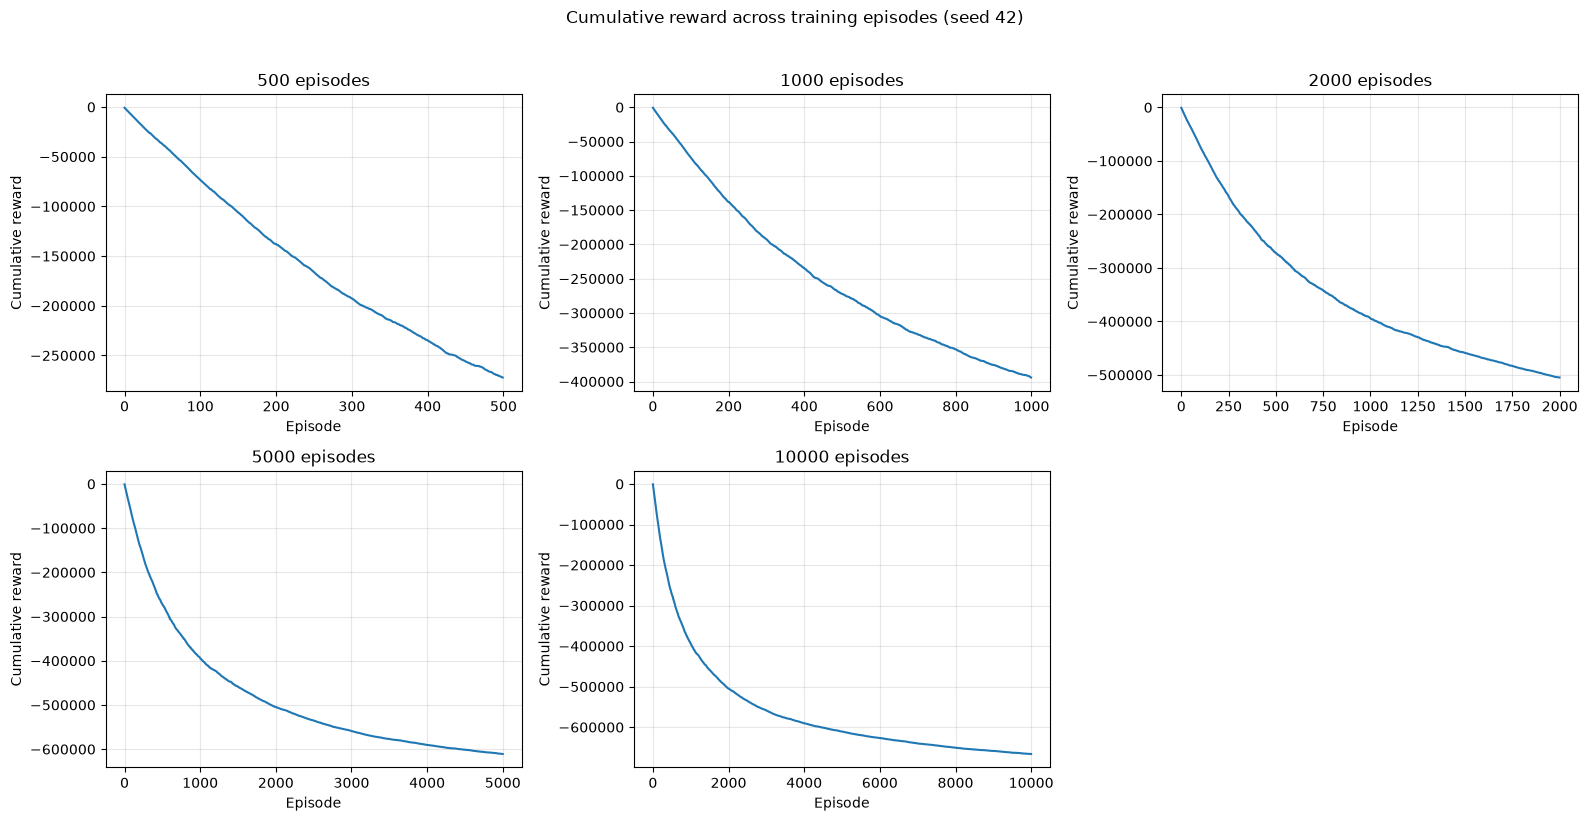

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, num_episodes in zip(axes, episode_configs):
    r = results[num_episodes]
    ax.plot(r["cumulative_reward"], color="tab:blue")
    ax.set_title(f"{num_episodes} episodes")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Cumulative reward")
    ax.grid(True, alpha=0.3)

axes[-1].axis("off")
fig.suptitle("Cumulative reward across training episodes (seed 42)", y=1.02)
fig.tight_layout()
plt.show()

Average reward over the most recent 100 episodes
- Cumulative reward mixes together the agent's worst, most exploratory episodes with its best, most trained ones, so it cannot show whether the agent is currently doing well or badly, only the running total of how it has done so far.
- A rolling window average of the last 100 episode rewards answers that instead, it rises while the agent is improving and flattens once the policy stabilises, and for Taxi it climbs from deeply negative toward zero as fewer episodes end in a 200-step timeout, even within these training budgets it may not fully cross into positive territory, which itself shows how much further training this environment can still absorb.
- Overlaying all five configurations on one plot (up to each run's own length) shows whether extra episodes keep improving the rolling average or whether it has already plateaued.

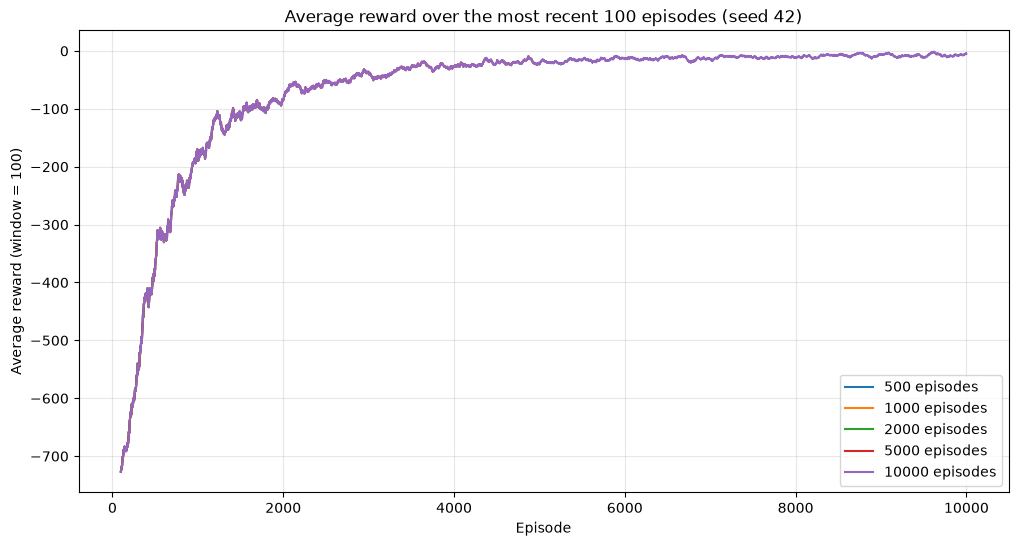

In [7]:
window_size = 100

plt.figure(figsize=(12, 6))
for num_episodes in episode_configs:
    rewards = results[num_episodes]["episode_rewards"]
    if len(rewards) >= window_size:
        moving_avg = np.convolve(rewards, np.ones(window_size) / window_size, mode="valid")
        x = np.arange(len(moving_avg)) + window_size - 1
    else:
        moving_avg = np.array(rewards)
        x = np.arange(len(moving_avg))
    plt.plot(x, moving_avg, label=f"{num_episodes} episodes")

plt.title(f"Average reward over the most recent {window_size} episodes (seed 42)")
plt.xlabel("Episode")
plt.ylabel("Average reward (window = 100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Test success rate after training
- Each trained Q-table is tested for 100 episodes with epsilon = 0, so every action is the greedy, learned action and no exploration noise is left, and the bar height is the mean of that measurement across the 5 training seeds.
- Because Taxi's transitions are deterministic, a failed test episode is not bad luck, it means the greedy policy still could not complete that particular pickup-and-drop-off within 200 steps, so success rate here is a strict measure of how completely the Q-table has converged across its 500 states.
- With 500 states and 3000 state-action pairs to learn, this environment is harder to fully solve than a small grid, so the comparison across configurations is expected to show steady improvement rather than an early plateau.

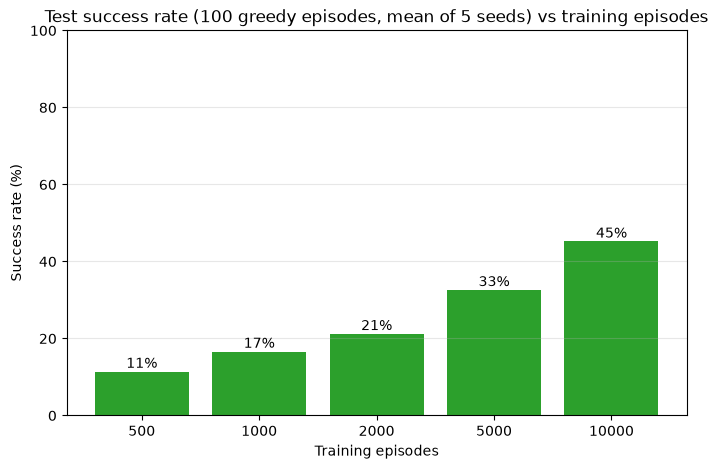

In [8]:
success_rates = [results[n]["success_rate"] for n in episode_configs]

plt.figure(figsize=(8, 5))
bars = plt.bar([str(n) for n in episode_configs], success_rates, color="tab:green")
for bar, rate in zip(bars, success_rates):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{rate:.0f}%", ha="center")
plt.title("Test success rate (100 greedy episodes, mean of 5 seeds) vs training episodes")
plt.xlabel("Training episodes")
plt.ylabel("Success rate (%)")
plt.ylim(0, 100)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

Visualising the environment
- render_mode is set to rgb_array instead of the continuous human window, since a notebook cannot host a live continuous render loop, a single rgb_array frame is captured and shown with imshow instead.
- The image shows the 5x5 grid with the four marked pickup and drop-off locations, the taxi, and the passenger, whichever state a reset happens to land on.

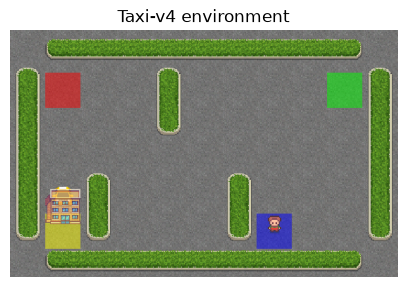

In [9]:
render_env = gym.make("Taxi-v4", render_mode="rgb_array")
render_env.reset(seed=0)
frame = render_env.render()
render_env.close()

plt.figure(figsize=(5, 5))
plt.imshow(frame)
plt.axis("off")
plt.title("Taxi-v4 environment")
plt.show()

Visualising the agent's moves
- A single static frame only shows one state, it does not show the agent actually acting, so the trained policy (from the 10000-episode run) is rolled out greedily, epsilon = 0, for one test episode, and every intermediate frame is captured with render_mode = rgb_array.
- The frames are shown as a static filmstrip rather than a continuous animation, for the same reason the earlier single frame used rgb_array, a notebook cannot host a live, continuously updating render loop.
- The Q-table at this training budget only reaches a 45 percent mean test success rate, so most random seeds would time out at 200 steps and produce an unreadably long filmstrip, a seed is searched for that gives a short, successful rollout purely so the filmstrip is legible, this search only changes which episode is displayed, it does not change the Q-table or any of the reported metrics above.

Rollout used seed 1, finished in 12 steps, terminated = True


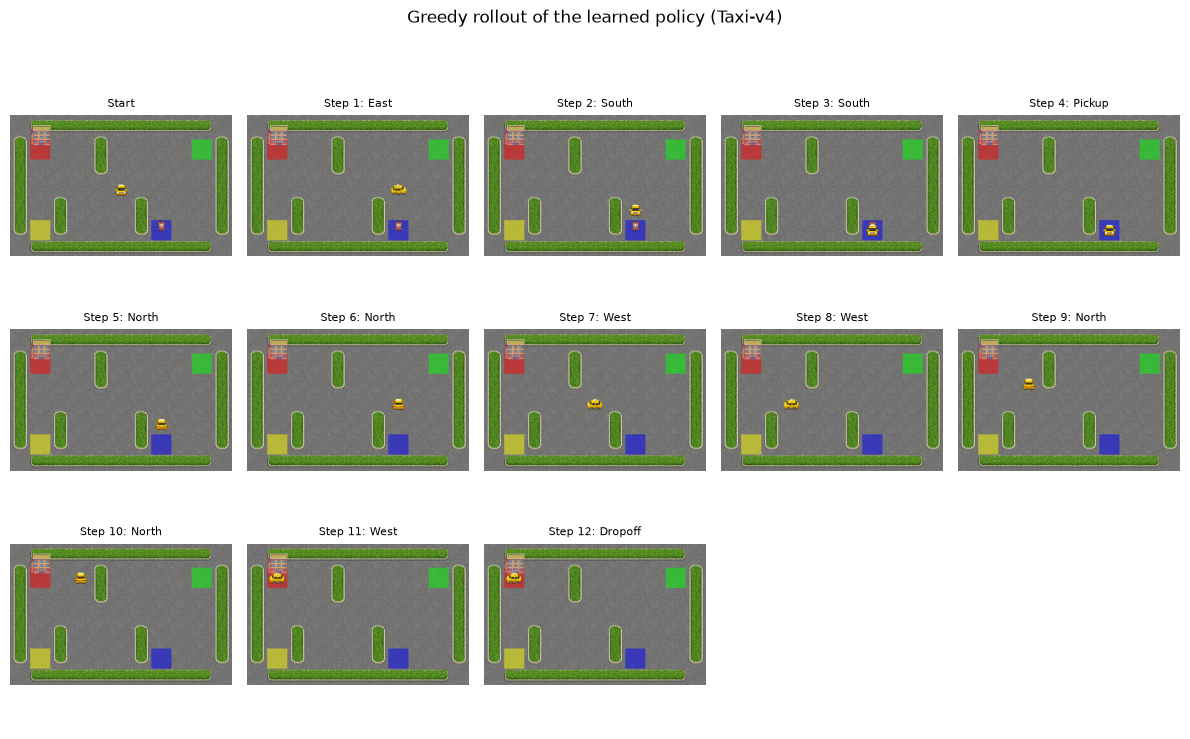

In [10]:
def find_demo_seed(q_table, max_search=300, max_steps_display=15):
    for seed in range(max_search):
        search_env = gym.make("Taxi-v4")
        state, info = search_env.reset(seed=seed)
        done, terminated, steps = False, False, 0
        while not done and steps < max_steps_per_episode:
            action = np.argmax(q_table[state])
            state, reward, terminated, truncated, info = search_env.step(action)
            done = terminated or truncated
            steps += 1
        search_env.close()
        if terminated and steps <= max_steps_display:
            return seed
    return None


best_num_episodes = max(episode_configs)
best_q_table = results[best_num_episodes]["q_table"]

action_names = {0: "South", 1: "North", 2: "East", 3: "West", 4: "Pickup", 5: "Dropoff"}
demo_seed = find_demo_seed(best_q_table)

rollout_env = gym.make("Taxi-v4", render_mode="rgb_array")
state, info = rollout_env.reset(seed=demo_seed)

frames = [rollout_env.render()]
step_labels = ["Start"]
done = False

while not done:
    action = np.argmax(best_q_table[state])
    state, reward, terminated, truncated, info = rollout_env.step(action)
    done = terminated or truncated
    frames.append(rollout_env.render())
    step_labels.append(f"Step {len(step_labels)}: {action_names[action]}")

rollout_env.close()
print(f"Rollout used seed {demo_seed}, finished in {len(frames) - 1} steps, terminated = {terminated}")

cols = 5
rows = int(np.ceil(len(frames) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.4, rows * 2.4))
axes = np.array(axes).reshape(-1)

for i, ax in enumerate(axes):
    if i < len(frames):
        ax.imshow(frames[i])
        ax.set_title(step_labels[i], fontsize=8)
    ax.axis("off")

fig.suptitle("Greedy rollout of the learned policy (Taxi-v4)", y=1.02)
fig.tight_layout()
plt.show()

Extracting and visualising the learned policy
- The policy for a state is the action with the highest Q-value in that state's row of the Q-table, np.argmax(q_table, axis=1).
- The Q-table used here is the representative (seed 42) table from the 10000-episode run, since it had the most training and the highest test success rate, so its policy is the most representative of what the agent actually learned.
- A Taxi policy naturally has two phases, driving to the passenger and picking them up, then driving to the destination and dropping them off, so the policy is shown as two 5x5 grids, one per phase, with the taxi's action at every possible grid cell for a fixed passenger and destination combination.
- P and D only mean anything at the passenger's own cell and the destination's own cell, seeing a P or D anywhere else means the Q-table has not fully converged for that state yet.

In [11]:
best_num_episodes = max(episode_configs)
best_q_table = results[best_num_episodes]["q_table"]
optimal_policy = np.argmax(best_q_table, axis=1)

taxi_env = gym.make("Taxi-v4").unwrapped
location_names = {0: "R", 1: "G", 2: "Y", 3: "B"}
arrow_symbols = {0: "↓", 1: "↑", 2: "→", 3: "←", 4: "P", 5: "D"}

pickup_location = 2    # Y
dropoff_location = 0   # R
passenger_in_taxi = 4

print(f"Learned policy (from the {best_num_episodes}-episode run)\n")

print(f"Phase 1: passenger waiting at {location_names[pickup_location]}, taxi should drive there and pick up")
for row in range(5):
    line = ""
    for col in range(5):
        state = taxi_env.encode(row, col, pickup_location, dropoff_location)
        line += f" {arrow_symbols[optimal_policy[state]]} "
    print(line)

print(f"\nPhase 2: passenger on board, taxi should drive to {location_names[dropoff_location]} and drop off")
for row in range(5):
    line = ""
    for col in range(5):
        state = taxi_env.encode(row, col, passenger_in_taxi, dropoff_location)
        line += f" {arrow_symbols[optimal_policy[state]]} "
    print(line)

Learned policy (from the 10000-episode run)

Phase 1: passenger waiting at Y, taxi should drive there and pick up
 ←  ↓  ←  ↑  ← 
 ↓  ↑  →  ↑  ← 
 ↓  ←  ←  →  ↓ 
 ↓  ↑  ↓  ↓  ← 
 P  →  ←  ←  ↓ 

Phase 2: passenger on board, taxi should drive to R and drop off
 D  ←  ↓  ↓  ← 
 ↑  ↑  ↓  ↓  ← 
 →  ↑  ←  ←  ← 
 ↑  ↑  ↑  ↑  ← 
 ↑  ↑  ↑  ↑  ← 


Inference
- Increasing the number of training episodes increases the final cumulative reward, the rolling average reward, the mean test success rate, and the mean test episode reward, all four metrics agree with each other, this is a much larger and harder state space than a small grid, so more experience translates directly into a more complete Q-table rather than hitting an early ceiling.
- Starting epsilon at 1.0 and decaying it toward 0.01 at a fixed rate means the 500 and 1000-episode budgets end training while epsilon is still comparatively high, so a sizeable share of their episodes are still exploratory when the run stops, this directly explains why their success rate and mean reward are both the lowest and the noisiest across the 5 seeds.
- Because Taxi charges -1 per step and -10 for illegal actions, the cumulative reward curve keeps decreasing across every configuration tested here, comparing its final value across configurations is not meaningful on its own, a longer run simply sums more mostly-negative terms, what matters is that its downward slope visibly flattens as training progresses, this is a clear demonstration of why cumulative reward alone is an unreliable progress signal, in this environment it is not simply flat and uninformative early on, its raw value can look worse for a longer, better-trained run while the underlying policy is, in fact, much improved.
- The moving average climbing steadily toward zero is a much clearer training-progress signal than the cumulative reward curve, and it climbs further for larger episode budgets, directly reflecting how much of a shorter run was still spent on costly random exploration rather than a converged policy.
- Because Taxi's transitions are deterministic, the test success rate is a strict measure of convergence rather than a ceiling imposed by environment randomness, so it climbing steadily from roughly 10 percent at 500 episodes toward the mid-40s percent at 10000 episodes shows the agent is still meaningfully learning at every one of these training budgets, unlike a small environment that can fully converge within a few thousand episodes.
- The two-phase policy grids show the agent correctly identifying the pickup action exactly at the passenger's own cell and the drop-off action exactly at the destination's own cell, with most surrounding cells pointing plausibly toward that target, the handful of cells that still point the wrong way are precisely the states that have not been visited enough times yet at this training budget, consistent with the moderate success rate at 10000 episodes.